<a href="https://colab.research.google.com/github/naveenmucherla/LeafGuard/blob/main/Plant_Disease_Detection_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 — Mount Google Drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Step 2 — Check the ZIP

In [ ]:
import os

ZIP_PATH = "/content/drive/MyDrive/DL_WorkShop/plantdisease.zip"

print("ZIP exists:", os.path.exists(ZIP_PATH))
print("ZIP path:", ZIP_PATH)

ZIP exists: True
ZIP path: /content/drive/MyDrive/DL_WorkShop/plantdisease.zip


Step 3 — Extract Dataset

In [ ]:
import zipfile
import os

EXTRACT_PATH = "/content/plant_dataset"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully!")

Dataset extracted successfully!


Step 4 — Find the actual PlantVillage folder automatically

In [ ]:
import os

print("Searching for PlantVillage folder...\n")

for root, dirs, files in os.walk(EXTRACT_PATH):
    if "PlantVillage" in dirs:
        PLANTVILLAGE_PATH = os.path.join(root, "PlantVillage")
        print("PlantVillage found at:")
        print(PLANTVILLAGE_PATH)
        break
else:
    PLANTVILLAGE_PATH = None
    print("PlantVillage folder not found.")

Searching for PlantVillage folder...

PlantVillage found at:
/content/plant_dataset/PlantVillage


Step 5 — Check the 15 classes

In [ ]:
class_folders = sorted([
    folder for folder in os.listdir(PLANTVILLAGE_PATH)
    if os.path.isdir(os.path.join(PLANTVILLAGE_PATH, folder))
])

print("Number of classes:", len(class_folders))

print("\nClasses:")
for i, folder in enumerate(class_folders):
    print(f"{i}: {folder}")

Number of classes: 15

Classes:
0: Pepper__bell___Bacterial_spot
1: Pepper__bell___healthy
2: Potato___Early_blight
3: Potato___Late_blight
4: Potato___healthy
5: Tomato_Bacterial_spot
6: Tomato_Early_blight
7: Tomato_Late_blight
8: Tomato_Leaf_Mold
9: Tomato_Septoria_leaf_spot
10: Tomato_Spider_mites_Two_spotted_spider_mite
11: Tomato__Target_Spot
12: Tomato__Tomato_YellowLeaf__Curl_Virus
13: Tomato__Tomato_mosaic_virus
14: Tomato_healthy


Step 6 — NOW Load the Dataset

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    PLANTVILLAGE_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    PLANTVILLAGE_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("\nNumber of classes:", len(class_names))
print("Classes:", class_names)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.

Number of classes: 15
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


Step 7 — Visualize the Dataset

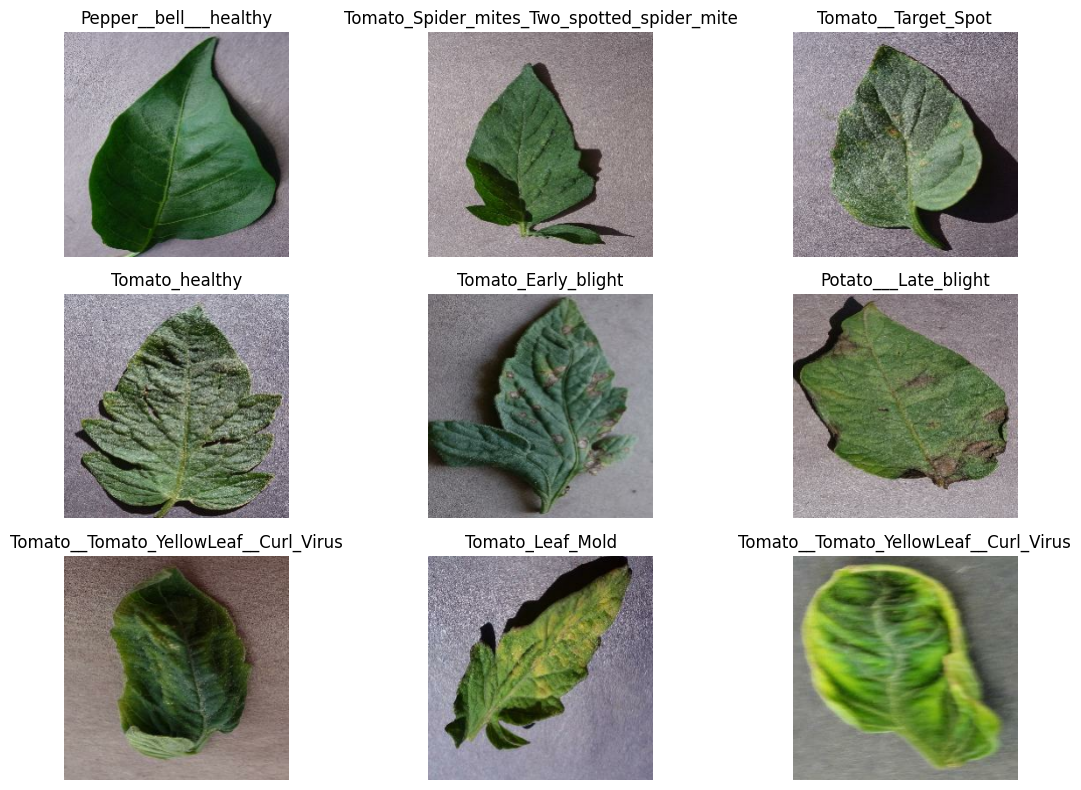

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

Step 8 — Check Class Distribution

In [ ]:
import os
from collections import Counter

class_counts = {}

for class_name in class_names:
    class_path = os.path.join(PLANTVILLAGE_PATH, class_name)

    image_count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    class_counts[class_name] = image_count

print("Class Distribution:\n")

for class_name, count in class_counts.items():
    print(f"{class_name:55} : {count}")

Class Distribution:

Pepper__bell___Bacterial_spot                           : 997
Pepper__bell___healthy                                  : 1478
Potato___Early_blight                                   : 1000
Potato___Late_blight                                    : 1000
Potato___healthy                                        : 152
Tomato_Bacterial_spot                                   : 2127
Tomato_Early_blight                                     : 1000
Tomato_Late_blight                                      : 1909
Tomato_Leaf_Mold                                        : 952
Tomato_Septoria_leaf_spot                               : 1771
Tomato_Spider_mites_Two_spotted_spider_mite             : 1676
Tomato__Target_Spot                                     : 1404
Tomato__Tomato_YellowLeaf__Curl_Virus                   : 3208
Tomato__Tomato_mosaic_virus                             : 373
Tomato_healthy                                          : 1591


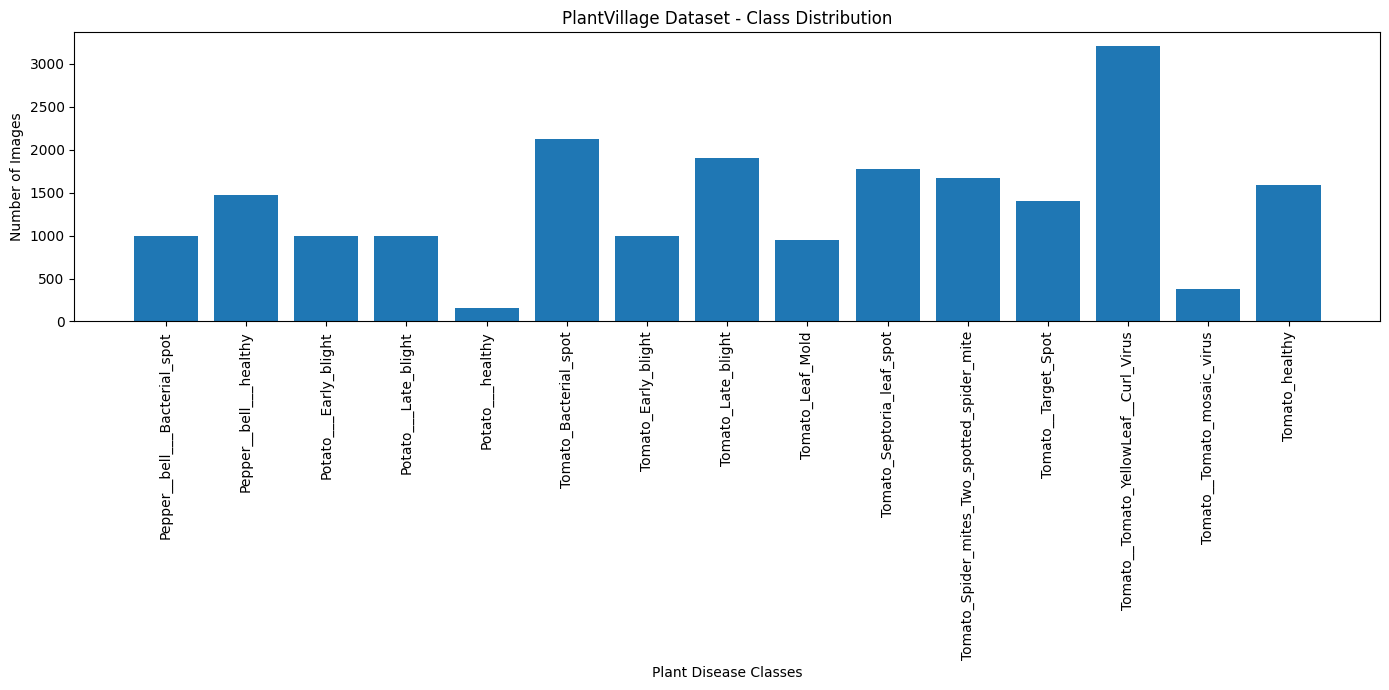

In [ ]:
plt.figure(figsize=(14, 7))

plt.bar(
    range(len(class_counts)),
    class_counts.values()
)

plt.xticks(
    range(len(class_counts)),
    class_counts.keys(),
    rotation=90
)

plt.xlabel("Plant Disease Classes")
plt.ylabel("Number of Images")
plt.title("PlantVillage Dataset - Class Distribution")

plt.tight_layout()
plt.show()

Step 9 — Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.1)
])

print("Data augmentation pipeline created successfully.")

Data augmentation pipeline created successfully.


Visualize the augmentation

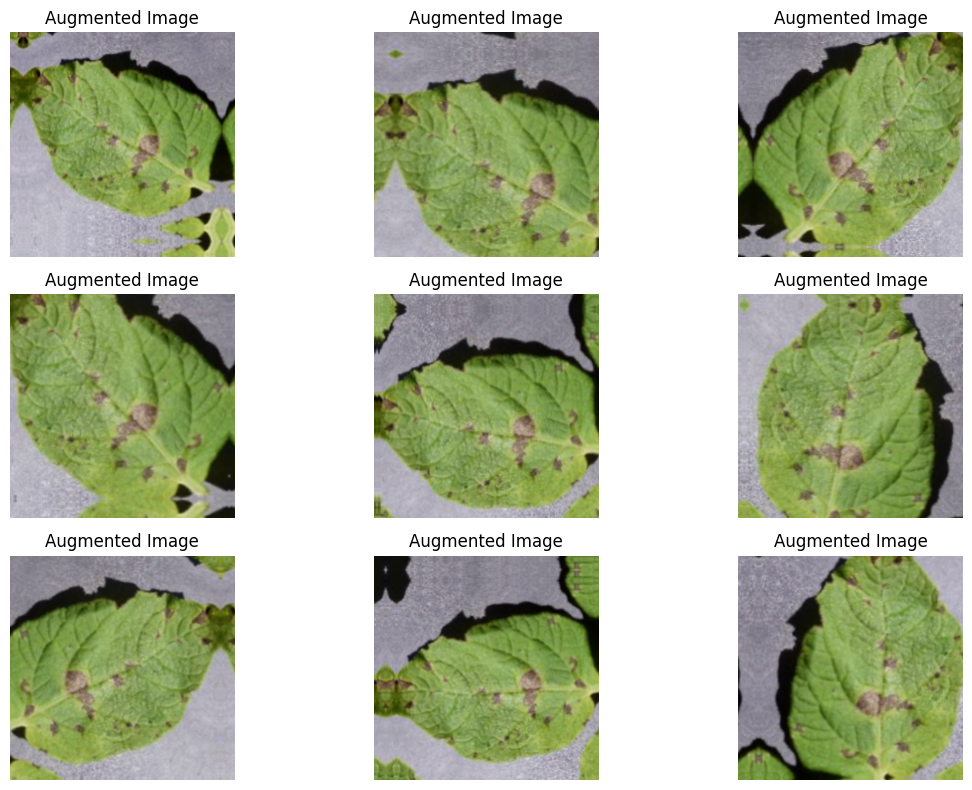

In [ ]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    original_image = images[0]

    for i in range(9):

        augmented_image = data_augmentation(
            tf.expand_dims(original_image, axis=0),
            training=True
        )[0]

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            tf.cast(
                tf.clip_by_value(augmented_image, 0, 255),
                tf.uint8
            )
        )

        plt.title("Augmented Image")
        plt.axis("off")

plt.tight_layout()
plt.show()

We don't create new images manually. Data augmentation generates slightly modified versions of existing training images, helping the model generalize better and reducing overfitting.

Step 10 — Optimize Dataset Loading

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized.")

Dataset pipeline optimized.


Step 11 — Load MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

print("MobileNetV2 loaded successfully!")
print("Total layers:", len(base_model.layers))
print("Trainable:", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 loaded successfully!
Total layers: 154
Trainable: False


Step 12 — Build Our Classification Model

In [ ]:
from tensorflow.keras import layers, models, regularizers

inputs = layers.Input(shape=(224, 224, 3))

# Day 4: Data Augmentation
x = data_augmentation(inputs)

# MobileNetV2 preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Day 3: Transfer Learning
x = base_model(x, training=False)

# Feature extraction
x = layers.GlobalAveragePooling2D()(x)

# Day 4: Dropout
x = layers.Dropout(0.30)(x)

# Day 4: L2 Regularization
x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(x)

# Additional Dropout
x = layers.Dropout(0.20)(x)

# 15-class classification
outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

224 × 224 × 3 Image

        ↓
Data Augmentation

        ↓
MobileNetV2
(Pretrained on ImageNet)

        ↓
Feature Extraction

        ↓
Global Average Pooling

        ↓
Dropout 30%

        ↓
Dense 128 + ReLU

        ↓
L2 Regularization

        ↓
Dropout 20%

        ↓
Dense 15 + Softmax

        ↓
Plant Disease Class

Step 13 — Compile the Model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


Step 14 — Add Early Stopping

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Early stopping configured!")

Early stopping configured!


Step 14 — Train

Now we're finally ready to train.

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.4449 - loss: 2.0232 - val_accuracy: 0.7264 - val_loss: 1.2013
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 76s 77ms/step - accuracy: 0.6699 - loss: 1.2474 - val_accuracy: 0.7902 - val_loss: 0.9088
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 40s 77ms/step - accuracy: 0.7371 - loss: 1.0360 - val_accuracy: 0.8083 - val_loss: 0.8073
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 40s 77ms/step - accuracy: 0.7639 - loss: 0.9310 - val_accuracy: 0.8251 - val_loss: 0.7397
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.7747 - loss: 0.8823 - val_accuracy: 0.8377 - val_loss: 0.6845
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.7924 - loss: 0.8279 - val_accuracy: 0.8430 - val_loss: 0.6604
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.8026 - loss: 0.7827 - val_accuracy: 0.8483 - val_loss: 0.6327
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.8099 - loss: 0.7496 - 

Step 15 — Plot Training Performance

Cell 1 — Accuracy

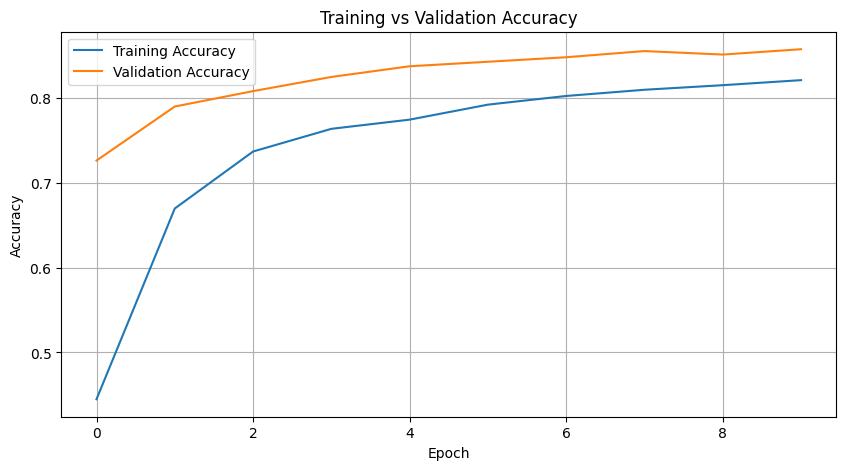

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Cell 2 — Loss

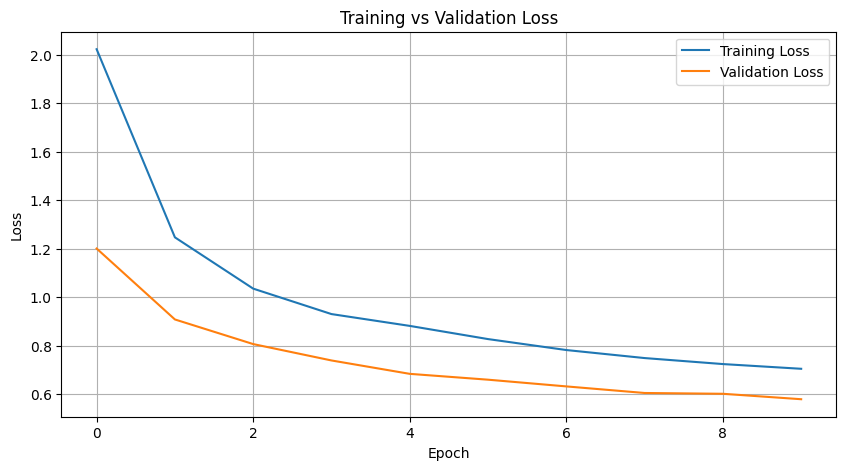

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

Training Accuracy ↑

Validation Accuracy ↑

Training Loss ↓

Validation Loss ↓

Step 16 — Evaluate the Model

In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)

print("\n================================")
print("FINAL MODEL PERFORMANCE")
print("================================")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy * 100:.2f}%")

129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.8578 - loss: 0.5799

FINAL MODEL PERFORMANCE
Validation Loss     : 0.5799
Validation Accuracy : 85.78%


Step 17 — Save the Model

In [ ]:
MODEL_SAVE_PATH = "/content/drive/MyDrive/plant_disease_mobilenetv2.keras"

model.save(MODEL_SAVE_PATH)

print("Model saved successfully!")
print(MODEL_SAVE_PATH)

Model saved successfully!
/content/drive/MyDrive/plant_disease_mobilenetv2.keras


Step 18 — Generate Predictions

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Prediction completed!")
print("Total validation samples:", len(y_true))

Prediction completed!
Total validation samples: 4127


Step 19 — Classification Report

This is an important placement/interview-level evaluation step.

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.93      0.92      0.93       200
                     Pepper__bell___healthy       0.95      0.98      0.96       302
                      Potato___Early_blight       0.97      0.95      0.96       189
                       Potato___Late_blight       0.82      0.93      0.87       188
                           Potato___healthy       0.87      0.84      0.85        31
                      Tomato_Bacterial_spot       0.74      0.95      0.83       441
                        Tomato_Early_blight       0.93      0.28      0.43       191
                         Tomato_Late_blight       0.90      0.87      0.89       341
                           Tomato_Leaf_Mold       0.78      0.82      0.80       185
                  Tomato_Septoria_leaf_spot       0.88      0.74      0.80       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.72      0.87

Precision

Of the images predicted as a particular disease, how many were actually that disease?

Recall

Of all actual images belonging to a disease, how many did our model correctly detect?

F1-score

Harmonic mean of precision and recall.

This makes the project much stronger than simply saying:

"My model achieved 86% accuracy."

Step 20 — Confusion Matrix

Now we'll visualize which diseases the model confuses with each other.

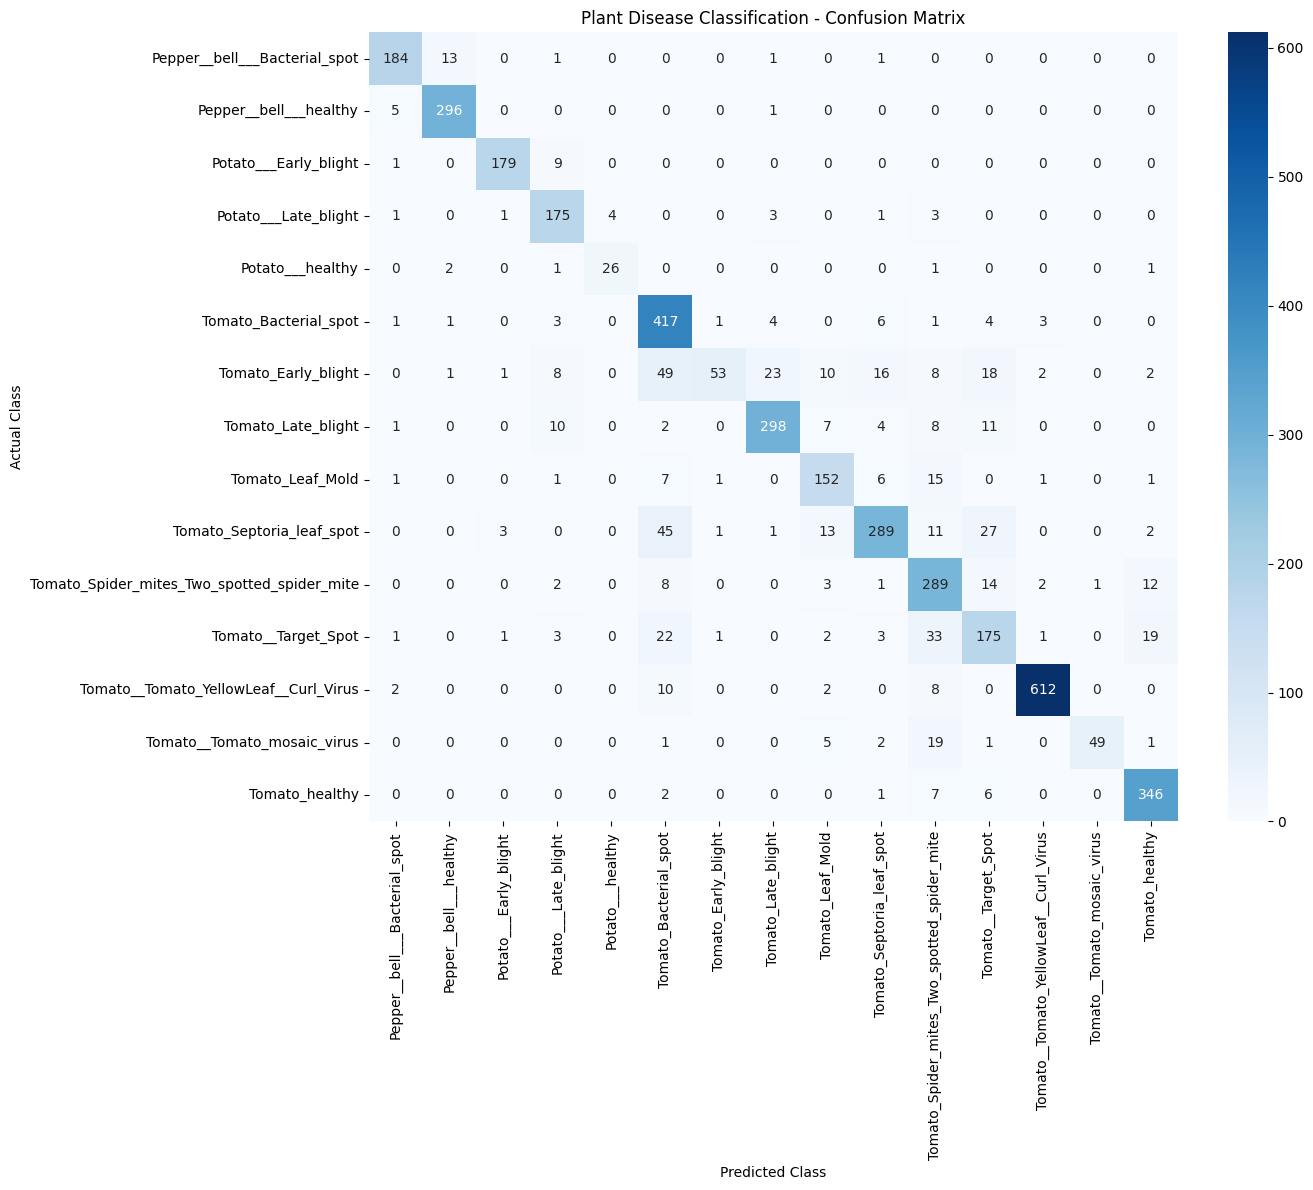

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Plant Disease Classification - Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Actual Disease

      ↓
     Model
     
      ↓
Predicted Disease

The diagonal cells represent correct predictions.

Off-diagonal cells represent misclassifications.

Step 21 — Test Prediction on One Image

Before Grad-CAM, let's make sure our model predicts an individual image correctly

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Select a random class
random_class = random.choice(class_names)

class_path = os.path.join(
    PLANTVILLAGE_PATH,
    random_class
)

# Select a random image
image_files = [
    f for f in os.listdir(class_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random_image = random.choice(image_files)

image_path = os.path.join(
    class_path,
    random_image
)

print("Actual Class:", random_class)
print("Image:", random_image)
print("Path:", image_path)

Actual Class: Tomato_Bacterial_spot
Image: f0793e2c-2033-4511-ba00-dbd2c42ce3c1___GCREC_Bact.Sp 3226.JPG
Path: /content/plant_dataset/PlantVillage/Tomato_Bacterial_spot/f0793e2c-2033-4511-ba00-dbd2c42ce3c1___GCREC_Bact.Sp 3226.JPG


Step 22 — Predict the Image

In [ ]:
img = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(img)

img_batch = tf.expand_dims(img_array, axis=0)

prediction = model.predict(img_batch, verbose=0)

predicted_index = np.argmax(prediction[0])

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index] * 100

print("================================")
print("PLANT DISEASE PREDICTION")
print("================================")
print("Actual Class     :", random_class)
print("Predicted Class  :", predicted_class)
print(f"Confidence       : {confidence:.2f}%")

PLANT DISEASE PREDICTION
Actual Class     : Tomato_Bacterial_spot
Predicted Class  : Tomato_Bacterial_spot
Confidence       : 99.19%


Step 23 — Display the Image

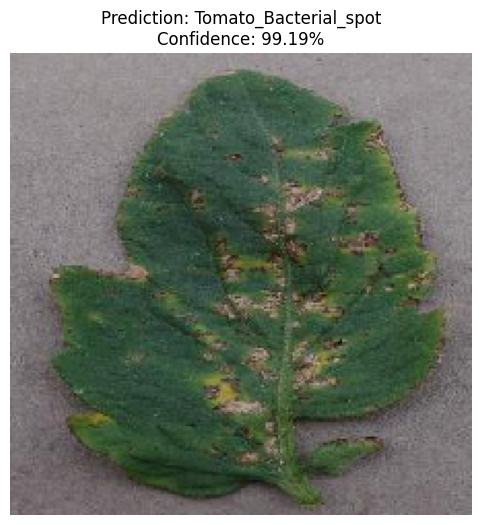

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

Step 24 — Find MobileNetV2's Last Convolutional Layer

Now we're going to implement Grad-CAM.

First inspect the MobileNetV2 layers.

In [ ]:
# Show our complete model layers

for i, layer in enumerate(model.layers):
    print(
        i,
        "->",
        layer.name,
        "->",
        layer.__class__.__name__
    )

0 -> input_layer_2 -> InputLayer
1 -> sequential -> Sequential
2 -> mobilenetv2_1.00_224 -> Functional
3 -> global_average_pooling2d -> GlobalAveragePooling2D
4 -> dropout -> Dropout
5 -> dense -> Dense
6 -> dropout_1 -> Dropout
7 -> dense_1 -> Dense


Step 25 — Create Grad-CAM Model

In [ ]:
# MobileNetV2 feature extractor
gradcam_base = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.get_layer("out_relu").output
)

print("Grad-CAM base model created!")

Grad-CAM base model created!


Step 26 — Get the trained classification head

Now we'll identify the layers after MobileNetV2.

In [ ]:
# Classification head layers

gap_layer = model.get_layer(
    "global_average_pooling2d"
)

dense_layer = model.get_layer(
    "dense"
)

final_layer = model.layers[-1]

print("GAP layer :", gap_layer.name)
print("Dense layer:", dense_layer.name)
print("Final layer:", final_layer.name)

GAP layer : global_average_pooling2d
Dense layer: dense
Final layer: dense_1


Step 27 — Grad-CAM Function

In [ ]:
def generate_gradcam(img_array, predicted_index):

    img_array = tf.cast(img_array, tf.float32)

    # MobileNetV2 preprocessing
    img_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(
        img_array
    )

    with tf.GradientTape() as tape:

        # Get MobileNetV2 feature maps
        conv_outputs = gradcam_base(
            img_preprocessed,
            training=False
        )

        # Watch feature maps
        tape.watch(conv_outputs)

        # Classification head
        x = gap_layer(conv_outputs)

        x = dense_layer(x)

        predictions = final_layer(x)

        # Score of predicted class
        class_score = predictions[:, predicted_index]

    # Calculate gradients
    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weighted feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # Remove negative values
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    heatmap = heatmap / (
        tf.reduce_max(heatmap)
        + tf.keras.backend.epsilon()
    )

    return heatmap.numpy()

Step 28 — Generate the Heatmap

In [ ]:
heatmap = generate_gradcam(
    img_batch,
    predicted_index
)

print("Grad-CAM generated successfully!")
print("Heatmap shape:", heatmap.shape)

Grad-CAM generated successfully!
Heatmap shape: (7, 7)


Step 29 — Display Grad-CAM Heatmap

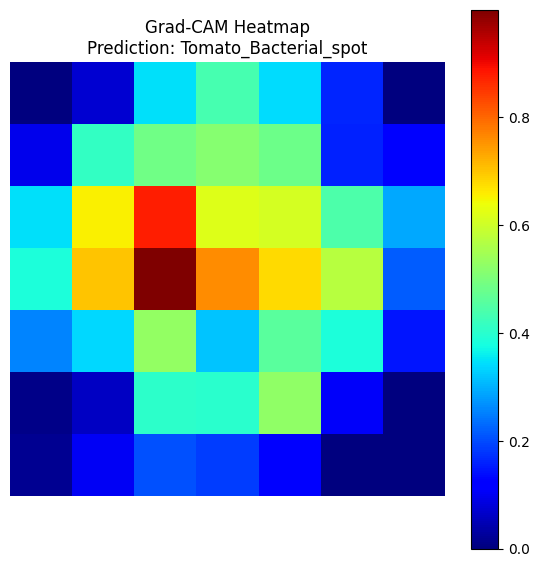

In [ ]:
plt.figure(figsize=(7, 7))

plt.imshow(heatmap, cmap="jet")

plt.title(
    f"Grad-CAM Heatmap\n"
    f"Prediction: {predicted_class}"
)

plt.colorbar()
plt.axis("off")

plt.show()

Step 30 — Overlay Grad-CAM on the Leaf

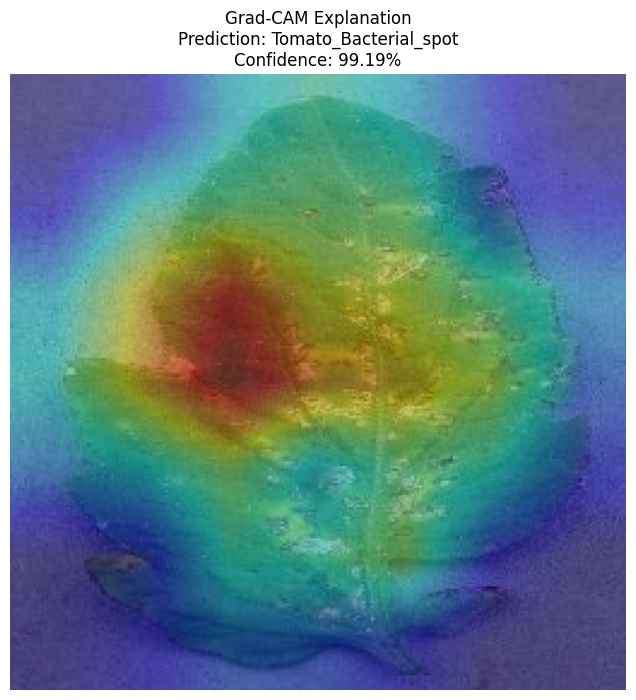

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read original image
original = cv2.imread(image_path)

# Convert BGR to RGB
original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)

# Resize Grad-CAM heatmap to original image size
heatmap_resized = cv2.resize(
    heatmap,
    (original.shape[1], original.shape[0])
)

# Convert heatmap to 0-255
heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

# Apply color map
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# Convert BGR to RGB
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay heatmap with original image
superimposed = cv2.addWeighted(
    original,
    0.6,
    heatmap_color,
    0.4,
    0
)

# Display
plt.figure(figsize=(8, 8))

plt.imshow(superimposed)

plt.title(
    f"Grad-CAM Explanation\n"
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

Step 31 — Better 3-Image Explanation

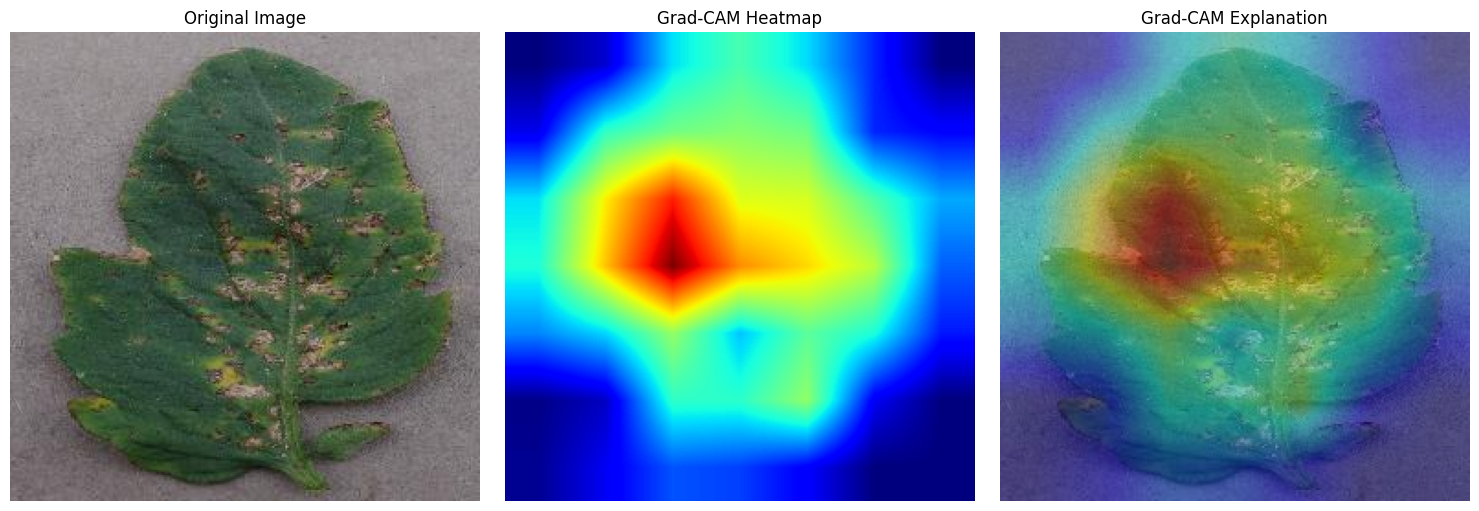

In [ ]:
plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

# Heatmap
plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

# Overlay
plt.subplot(1, 3, 3)
plt.imshow(superimposed)
plt.title("Grad-CAM Explanation")
plt.axis("off")

plt.tight_layout()
plt.show()

Why did you use Grad-CAM?

Our model predicts the plant disease, but Grad-CAM helps us understand which regions of the leaf contributed to that prediction. It provides a visual explanation of the CNN's decision."

Why is the heatmap only 7×7?

Because the final convolutional feature maps of MobileNetV2 have a much lower spatial resolution than the original 224×224 image. We resize the heatmap back to the original image dimensions for visualization.

What does the highlighted region mean?

It represents image regions that contributed more strongly to the selected class prediction.

Step 32 — Install Flask + ngrok

In [ ]:
!pip install -q flask pyngrok

Step 33 — Create the Flask Application

In [ ]:
from flask import Flask, request, render_template_string
import tensorflow as tf
import numpy as np
import os
import cv2
import base64
from PIL import Image
from io import BytesIO

app = Flask(__name__)

# ==========================================
# LOAD TRAINED MODEL
# ==========================================

MODEL_PATH = "/content/drive/MyDrive/plant_disease_mobilenetv2.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")

Model loaded successfully!


Step 34 — Flask HTML Interface

In [ ]:
HTML_PAGE = """
<!DOCTYPE html>

<html>

<head>

    <title>Plant Disease AI</title>

    <style>

        body {
            font-family: Arial, sans-serif;
            background: #f4f7f4;
            text-align: center;
            padding: 40px;
        }

        .container {
            max-width: 900px;
            margin: auto;
            background: white;
            padding: 30px;
            border-radius: 15px;
            box-shadow: 0 4px 15px rgba(0,0,0,0.15);
        }

        h1 {
            color: #2e7d32;
        }

        input {
            margin: 20px;
            padding: 10px;
        }

        button {
            background: #2e7d32;
            color: white;
            border: none;
            padding: 12px 25px;
            border-radius: 8px;
            cursor: pointer;
            font-size: 16px;
        }

        button:hover {
            background: #1b5e20;
        }

        img {
            max-width: 400px;
            margin: 15px;
            border-radius: 10px;
        }

        .result {
            margin-top: 25px;
            padding: 20px;
            background: #f1f8e9;
            border-radius: 10px;
        }

    </style>

</head>


<body>

<div class="container">

    <h1>🌱 Plant Disease Detection</h1>

    <p>Upload a plant leaf image to predict its disease.</p>

    <form method="POST" enctype="multipart/form-data">

        <input
            type="file"
            name="image"
            accept="image/*"
            required
        >

        <br>

        <button type="submit">
            Predict Disease
        </button>

    </form>


    {% if prediction %}

    <div class="result">

        <h2>Prediction Result</h2>

        <h3>{{ prediction }}</h3>

        <h3>Confidence: {{ confidence }}%</h3>

        <h3>Grad-CAM Explanation</h3>

        <img src="data:image/jpeg;base64,{{ gradcam }}">

    </div>

    {% endif %}

</div>

</body>

</html>
"""

Step 35 — Flask Prediction Function

Now connect the uploaded image to our trained model

In [ ]:
def predict_image(image):

    # Resize image
    image = image.resize((224, 224))

    # Convert to NumPy
    img_array = np.array(image)

    # Ensure RGB
    if img_array.shape[-1] == 4:
        img_array = img_array[:, :, :3]

    # Add batch dimension
    img_batch = np.expand_dims(
        img_array,
        axis=0
    )

    # Prediction
    predictions = model.predict(
        img_batch,
        verbose=0
    )

    predicted_index = np.argmax(
        predictions[0]
    )

    predicted_class = class_names[
        predicted_index
    ]

    confidence = (
        predictions[0][predicted_index] * 100
    )

    return (
        predicted_index,
        predicted_class,
        confidence,
        img_batch
    )

Step 36 — Flask Grad-CAM Function

We need to reuse the Grad-CAM logic that successfully worked.

In [ ]:
def flask_gradcam(img_batch, predicted_index):

    img_array = tf.cast(
        img_batch,
        tf.float32
    )

    # MobileNetV2 preprocessing
    img_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(
        img_array
    )

    with tf.GradientTape() as tape:

        # MobileNetV2 feature extraction
        conv_outputs = gradcam_base(
            img_preprocessed,
            training=False
        )

        tape.watch(conv_outputs)

        # Classification head
        x = gap_layer(conv_outputs)

        x = dense_layer(x)

        predictions = final_layer(x)

        class_score = predictions[
            :,
            predicted_index
        ]

    # Gradients
    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    # Average gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(1, 2)
    )

    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weighted feature maps
    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Normalize
    heatmap = heatmap / (
        tf.reduce_max(heatmap)
        + tf.keras.backend.epsilon()
    )

    return heatmap.numpy()

Step 37 — Convert Grad-CAM to Web Image

In [ ]:
def create_gradcam_image(img_batch, heatmap):

    # Original image
    original = img_batch[0].astype(
        np.uint8
    )

    # Resize heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (224, 224)
    )

    # Convert to 0-255
    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )

    # Apply color map
    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    # BGR → RGB
    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Overlay
    overlay = cv2.addWeighted(
        original,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    # Convert to PIL
    overlay_image = Image.fromarray(
        overlay
    )

    # Convert to bytes
    buffer = BytesIO()

    overlay_image.save(
        buffer,
        format="JPEG"
    )

    # Base64 for HTML
    encoded = base64.b64encode(
        buffer.getvalue()
    ).decode("utf-8")

    return encoded

Step 38 — Create Flask Route

This connects everything together.

In [ ]:
@app.route("/", methods=["GET", "POST"])
def home():

    prediction = None
    confidence = None
    gradcam_image = None

    if request.method == "POST":

        file = request.files["image"]

        if file:

            image = Image.open(
                file
            ).convert("RGB")

            (
                predicted_index,
                prediction,
                confidence,
                img_batch
            ) = predict_image(image)

            # Generate Grad-CAM
            heatmap = flask_gradcam(
                img_batch,
                predicted_index
            )

            # Convert heatmap to web image
            gradcam_image = create_gradcam_image(
                img_batch,
                heatmap
            )

            confidence = round(
                confidence,
                2
            )

    return render_template_string(
        HTML_PAGE,
        prediction=prediction,
        confidence=confidence,
        gradcam=gradcam_image
    )

Step 39 — Start Flask

In [ ]:
app.run(
    host="0.0.0.0",
    port=5000,
    debug=False
)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


Step 40 — Configure ngrok

In [ ]:
from getpass import getpass
import os

NGROK_AUTHTOKEN = getpass("Enter your ngrok authtoken: ")

os.environ["NGROK_AUTHTOKEN"] = NGROK_AUTHTOKEN

print("ngrok authtoken configured successfully.")

Enter your ngrok authtoken: ··········
ngrok authtoken configured successfully.


Step 41 — Start Flask in the Background

Instead of running Flask in the foreground, we'll run it in the background so Colab can continue executing cells.

In [ ]:
import threading

def run_flask():
    app.run(
        host="0.0.0.0",
        port=5000,
        debug=False,
        use_reloader=False
    )

flask_thread = threading.Thread(
    target=run_flask
)

flask_thread.daemon = True
flask_thread.start()

print("Flask server started on port 5000.")

Flask server started on port 5000. * Serving Flask app '__main__'

 * Debug mode: off


Step 42 — Start ngrok

In [ ]:
from pyngrok import ngrok

# Close any previous tunnels
ngrok.kill()

# Create public tunnel
public_url = ngrok.connect(
    5000,
    "http"
)

print("======================================")
print("🌍 PUBLIC PLANT DISEASE AI URL")
print("======================================")
print(public_url)

INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


🌍 PUBLIC PLANT DISEASE AI URL
NgrokTunnel: "https://granite-dividing-papyrus.ngrok-free.dev" -> "http://localhost:5000"
